In [10]:
import os, gc, time, random, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings("ignore")
SEED = 42
IMG_SIZE = 224
NUM_CLASSES = 37
BATCH_SIZE = 32

# Deliberately short exploratory runs: comparisons, not long training.
INIT_EPOCHS = 2
STUDY_EPOCHS = 3
CV_EPOCHS = 2
FINAL_EPOCHS = 6
PATIENCE = 1

RUN_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else os.getcwd()
IMAGES_DIR = os.path.join(RUN_DIR, "images")
TFDS_DIR = os.path.join(RUN_DIR, "tensorflow_datasets")
os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(TFDS_DIR, exist_ok=True)

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
GPUS = tf.config.list_physical_devices("GPU")
for gpu in GPUS:
    try: tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError: pass
tf.keras.mixed_precision.set_global_policy("mixed_float16" if GPUS else "float32")

print("TensorFlow:", tf.__version__)
print("GPU(s):", GPUS)
print("Mixed precision:", tf.keras.mixed_precision.global_policy())
print("Run directory:", RUN_DIR)


TensorFlow: 2.20.0
GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision: <DTypePolicy "mixed_float16">
Run directory: /kaggle/working


In [11]:
(ds_train_raw, ds_test_raw), info = tfds.load(
    "oxford_iiit_pet",
    split=["train", "test"],
    as_supervised=True,
    with_info=True,
    data_dir=TFDS_DIR
)

class_names = info.features["label"].names
assert len(class_names) == NUM_CLASSES

print("Classes:", NUM_CLASSES)
print("Training examples:", info.splits["train"].num_examples)
print("Test examples:", info.splits["test"].num_examples)
print("First 10 classes:", class_names[:10])

Classes: 37
Training examples: 3680
Test examples: 3669
First 10 classes: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair']


In [12]:
# Resize once and keep images as uint8.
# This avoids repeatedly resizing images and cuts host RAM roughly 4x vs float32.
def resize_uint8(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE), method="bilinear")
    return tf.cast(tf.clip_by_value(image, 0, 255), tf.uint8), label

def materialize_resized(ds, batch_size=128):
    images, labels = [], []
    pipe = ds.map(resize_uint8, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size)
    for xb, yb in pipe:
        images.append(xb.numpy()); labels.append(yb.numpy())
    return np.concatenate(images), np.concatenate(labels)

train_images, train_labels = materialize_resized(ds_train_raw)
print("Training array:", train_images.shape, train_images.dtype)
print(f"Training image RAM: {train_images.nbytes / 1024**2:.1f} MiB")


Training array: (3680, 224, 224, 3) uint8
Training image RAM: 528.3 MiB


In [13]:
# Fixed 80/20 stratified train/validation split.
# The test set remains completely independent.
from sklearn.model_selection import train_test_split

indices = np.arange(len(train_labels))
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    shuffle=True,
    stratify=train_labels
)

X_dev = train_images[train_idx]
y_dev = train_labels[train_idx]
X_val = train_images[val_idx]
y_val = train_labels[val_idx]

print("Development training:", X_dev.shape, y_dev.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Independent test:", info.splits["test"].num_examples)


Development training: (2944, 224, 224, 3) (2944,)
Validation: (736, 224, 224, 3) (736,)
Independent test: 3669


In [14]:
# Fast data pipelines + one-time pretrained feature cache.
AUTOTUNE = tf.data.AUTOTUNE

def mobilenet_preprocess(image, label):
    image = tf.cast(image, tf.float32)
    return tf.keras.applications.mobilenet_v2.preprocess_input(image), label

def make_array_dataset(X, y, batch_size=32, training=False, cache=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(min(len(y), 2048), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(mobilenet_preprocess, num_parallel_calls=AUTOTUNE)
    if cache: ds = ds.cache()
    return ds.batch(batch_size).prefetch(AUTOTUNE)

train_ds = make_array_dataset(X_dev, y_dev, BATCH_SIZE, training=True)
val_ds = make_array_dataset(X_val, y_val, BATCH_SIZE, training=False, cache=True)
test_ds = (ds_test_raw.map(resize_uint8, num_parallel_calls=AUTOTUNE)
           .map(mobilenet_preprocess, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE).prefetch(AUTOTUNE))

# Precompute frozen ImageNet MobileNetV2 representations ONCE for training/development data.
# Test data is deliberately NOT processed here; it remains untouched until final evaluation.
feature_base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet"
)
feature_base.trainable = False
feature_extractor = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    feature_base,
    tf.keras.layers.GlobalAveragePooling2D()
], name="cached_mobilenet_features")

def extract_features(X, y, batch_size=128):
    ds = make_array_dataset(X, y, batch_size=batch_size, training=False, cache=False)
    feats = feature_extractor.predict(ds, verbose=0)
    return feats.astype(np.float32), np.asarray(y)

print("Extracting frozen MobileNetV2 features once for training/development...")
X_dev_feat, y_dev_feat = extract_features(X_dev, y_dev)
X_val_feat, y_val_feat = extract_features(X_val, y_val)
X_full_feat, y_full_feat = extract_features(train_images, train_labels)
print("Cached features:", X_dev_feat.shape, X_val_feat.shape, X_full_feat.shape)

del feature_extractor, feature_base
tf.keras.backend.clear_session()
gc.collect()

def make_feature_dataset(X, y, batch_size=32, training=False, cache=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(min(len(y), 2048), seed=SEED, reshuffle_each_iteration=True)
    if cache: ds = ds.cache()
    return ds.batch(batch_size).prefetch(AUTOTUNE)

feature_train_ds = make_feature_dataset(X_dev_feat, y_dev_feat, BATCH_SIZE, True, True)
feature_val_ds = make_feature_dataset(X_val_feat, y_val_feat, BATCH_SIZE, False, True)
feature_full_train_ds = make_feature_dataset(X_full_feat, y_full_feat, BATCH_SIZE, True, True)

overall_results = []


Extracting frozen MobileNetV2 features once for training/development...
Cached features: (2944, 1280) (736, 1280) (3680, 1280)


In [15]:
# Model/optimizer helpers.
def make_optimizer(name, lr):
    name = name.lower()
    if name == "sgd": return tf.keras.optimizers.SGD(learning_rate=lr)
    if name == "momentum": return tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    if name == "rmsprop": return tf.keras.optimizers.RMSprop(learning_rate=lr)
    if name == "adam": return tf.keras.optimizers.Adam(learning_rate=lr)
    raise ValueError(name)

def make_model(weights="imagenet", train_base=False, dropout=0.0, l2=0.0,
               classifier_bn=True, opt="Adam", lr=1e-4, classifier_initializer=None):
    base = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights=weights
    )
    base.trainable = train_base
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")
    x = base(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    if classifier_bn: x = tf.keras.layers.BatchNormalization(name="classifier_bn")(x)
    if dropout > 0: x = tf.keras.layers.Dropout(dropout, name="dropout")(x)
    outputs = tf.keras.layers.Dense(
        NUM_CLASSES, activation="softmax",
        kernel_initializer=classifier_initializer,
        kernel_regularizer=tf.keras.regularizers.l2(l2) if l2 else None,
        dtype="float32", name="classifier"
    )(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=make_optimizer(opt, lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"], steps_per_execution=16)
    return model

def make_head_model(dropout=0.0, l2=0.0, classifier_bn=True, opt="Adam",
                    lr=1e-4, classifier_initializer=None):
    # This is the exact trainable classification head used after MobileNetV2 feature extraction.
    inputs = tf.keras.Input(shape=(1280,), name="mobilenetv2_features")
    x = inputs
    if classifier_bn: x = tf.keras.layers.BatchNormalization(name="classifier_bn")(x)
    if dropout > 0: x = tf.keras.layers.Dropout(dropout, name="dropout")(x)
    outputs = tf.keras.layers.Dense(
        NUM_CLASSES, activation="softmax",
        kernel_initializer=classifier_initializer,
        kernel_regularizer=tf.keras.regularizers.l2(l2) if l2 else None,
        dtype="float32", name="classifier"
    )(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=make_optimizer(opt, lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"], steps_per_execution=16)
    return model

def set_fine_tuning(model, unfreeze_last=10, lr=1e-5, opt="Adam"):
    base = model.get_layer(index=1)
    for layer in base.layers: layer.trainable = False
    for layer in base.layers[-unfreeze_last:]:
        layer.trainable = not isinstance(layer, tf.keras.layers.BatchNormalization)
    model.compile(optimizer=make_optimizer(opt, lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"], steps_per_execution=16)
    return model

def fit_model(model, epochs, data, validation=None):
    callbacks = []
    if validation is not None:
        callbacks.append(tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=PATIENCE, restore_best_weights=True, mode="max"
        ))
    return model.fit(data, validation_data=validation, epochs=epochs,
                     callbacks=callbacks, verbose=1)

def best_val_accuracy(history): return 100.0 * max(history.history["val_accuracy"])
def best_epoch(history): return int(np.argmax(history.history["val_accuracy"]) + 1)

def cleanup():
    tf.keras.backend.clear_session()
    gc.collect()

print("Optimized helpers ready.")

Optimized helpers ready.


## Weight Initialization

For this study, initialization is applied to **all convolutional, depthwise-convolutional, and classifier kernels of a MobileNetV2 instantiated without ImageNet weights**. Batch-normalization parameters are left at their standard initialization.

This makes the comparison a genuine initialization experiment rather than changing only the final classifier. Zero initialization is intentionally included because it demonstrates the symmetry/gradient problem expected from a poor initialization strategy.


In [16]:
# Initialization helpers: reinitialize all kernel-bearing layers.
def reinitialize_mobilenet(model, strategy):
    for layer in model.layers:
        # MobileNetV2 is nested as model.layers[1].
        if isinstance(layer, tf.keras.Model):
            for sub in layer.layers:
                if hasattr(sub, "kernel") and sub.kernel is not None:
                    sub.kernel.assign(strategy(sub.kernel.shape, dtype=sub.kernel.dtype))
                if hasattr(sub, "depthwise_kernel") and sub.depthwise_kernel is not None:
                    sub.depthwise_kernel.assign(
                        strategy(sub.depthwise_kernel.shape, dtype=sub.depthwise_kernel.dtype)
                    )
        elif hasattr(layer, "kernel") and layer.kernel is not None:
            layer.kernel.assign(strategy(layer.kernel.shape, dtype=layer.kernel.dtype))
    return model

initializers = {
    "Zero": tf.keras.initializers.Zeros(),
    "Random": tf.keras.initializers.RandomNormal(stddev=0.05, seed=SEED),
    "Xavier": tf.keras.initializers.GlorotUniform(seed=SEED),
    "He": tf.keras.initializers.HeNormal(seed=SEED),
}

init_histories = {}
init_times = {}

for name, initializer in initializers.items():
    print(f"\n=== Initialization: {name} ===")
    cleanup()
    model = make_model(
        weights=None,
        train_base=True,
        dropout=0.0,
        classifier_bn=True,
        opt="Adam",
        lr=1e-3,
    )
    model = reinitialize_mobilenet(model, initializer)
    start = time.time()
    h = fit_model(model, INIT_EPOCHS, train_ds, val_ds)
    init_histories[name] = h
    init_times[name] = (time.time() - start) / 60
    print(f"Best validation accuracy: {best_val_accuracy(h):.2f}%")


=== Initialization: Zero ===
Epoch 1/2


2026-08-30 08:48:30.298256: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 08:48:30.435559: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


92/92 ━━━━━━━━━━━━━━━━━━━━ 79s 855ms/step - accuracy: 0.0231 - loss: 3.6115 - val_accuracy: 0.0272 - val_loss: 3.6109
Epoch 2/2
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.0190 - loss: 3.6113 - val_accuracy: 0.0272 - val_loss: 3.6109
Best validation accuracy: 2.72%

=== Initialization: Random ===
Epoch 1/2
92/92 ━━━━━━━━━━━━━━━━━━━━ 63s 689ms/step - accuracy: 0.0482 - loss: 4.1123 - val_accuracy: 0.0272 - val_loss: 3.6488
Epoch 2/2
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - accuracy: 0.0815 - loss: 3.6449 - val_accuracy: 0.0272 - val_loss: 3.6578
Best validation accuracy: 2.72%

=== Initialization: Xavier ===
Epoch 1/2
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 695ms/step - accuracy: 0.0459 - loss: 4.0058 - val_accuracy: 0.0272 - val_loss: 3.6368
Epoch 2/2
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.0747 - loss: 3.6967 - val_accuracy: 0.0272 - val_loss: 3.6701
Best validation accuracy: 2.72%

=== Initialization: He ===
Epoch 1/2
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 692ms/step - acc

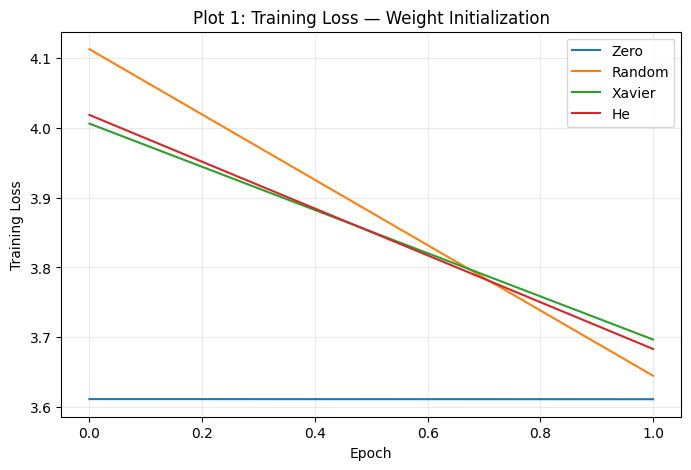

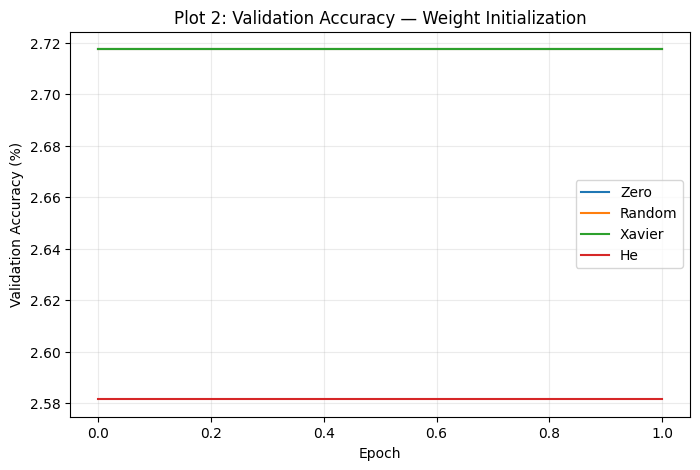

,Initialization,Best Val Accuracy (%),Best Epoch,Time (min)
0,Zero,2.717,1,1.456
1,Random,2.717,1,1.217
2,Xavier,2.717,1,1.231
3,He,2.582,1,1.238


In [17]:
# Plot 1: Training Loss vs Epoch — initialization
def savefig(filename):
    path = os.path.join(IMAGES_DIR, filename)
    plt.savefig(path, dpi=220, bbox_inches="tight")
    return path

plt.figure(figsize=(8, 5))
for name, h in init_histories.items():
    plt.plot(h.history["loss"], label=name)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Plot 1: Training Loss — Weight Initialization")
plt.legend()
plt.grid(alpha=0.25)
savefig("1_weight_init_loss.png")
plt.show()

# Plot 2: Validation Accuracy vs Epoch — initialization
plt.figure(figsize=(8, 5))
for name, h in init_histories.items():
    plt.plot(np.array(h.history["val_accuracy"]) * 100, label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 2: Validation Accuracy — Weight Initialization")
plt.legend()
plt.grid(alpha=0.25)
savefig("2_weight_init_accuracy.png")
plt.show()

init_summary = pd.DataFrame({
    "Initialization": list(init_histories),
    "Best Val Accuracy (%)": [best_val_accuracy(init_histories[k]) for k in init_histories],
    "Best Epoch": [best_epoch(init_histories[k]) for k in init_histories],
    "Time (min)": [init_times[k] for k in init_histories],
})
display(init_summary.round(3))

## Regularization and Batch Normalization

The controlled regularization study uses the same pretrained MobileNetV2 feature extractor and changes one mechanism at a time in the classification head:
- no added regularization,
- L2,
- Dropout,
- Batch Normalization.

The MobileNetV2 backbone itself already contains Batch Normalization layers. Therefore, the explicit BN comparison below refers to the **added classifier-head BN layer**, making the controlled change unambiguous.



=== Regularization: No Regularization ===
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1760 - loss: 3.1815 - val_accuracy: 0.3383 - val_loss: 2.6523
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5380 - loss: 2.1835 - val_accuracy: 0.6291 - val_loss: 1.8792
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7429 - loss: 1.5290 - val_accuracy: 0.7582 - val_loss: 1.3903

=== Regularization: L2 ===
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1515 - loss: 3.2359 - val_accuracy: 0.3274 - val_loss: 2.6638
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5183 - loss: 2.2271 - val_accuracy: 0.6277 - val_loss: 1.8882
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7371 - loss: 1.5710 - val_accuracy: 0.7690 - val_loss: 1.3936

=== Regularization: Dropout ===
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.0676 - loss: 3.8658 - val_accuracy: 0.1766 - val_loss: 3.0704
Epoch 2/3
92/92 ━━

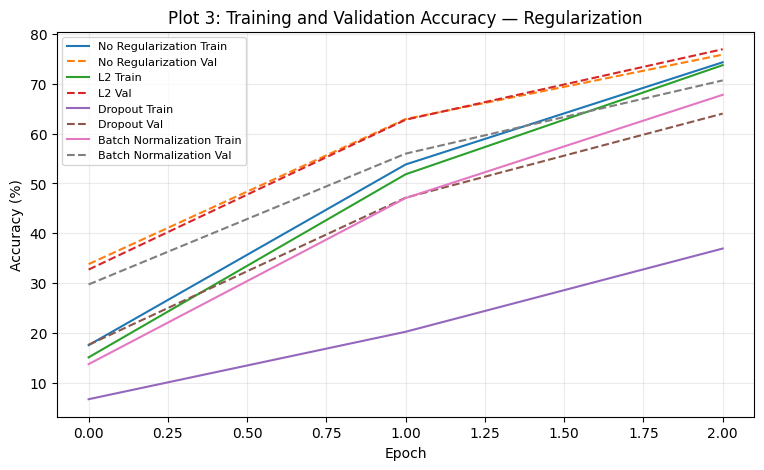

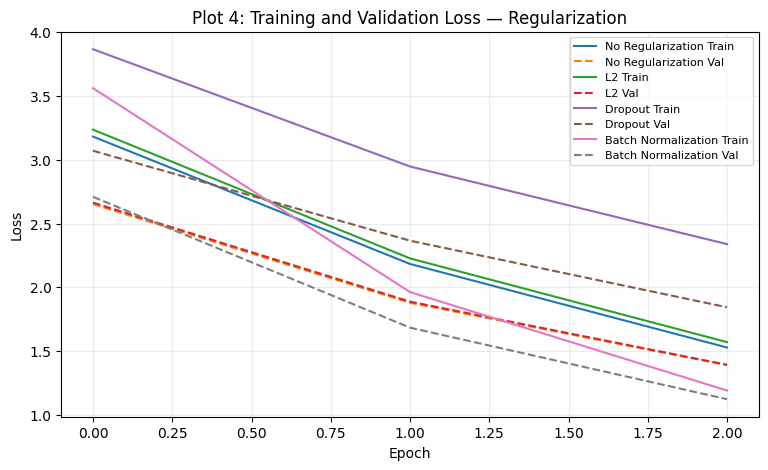

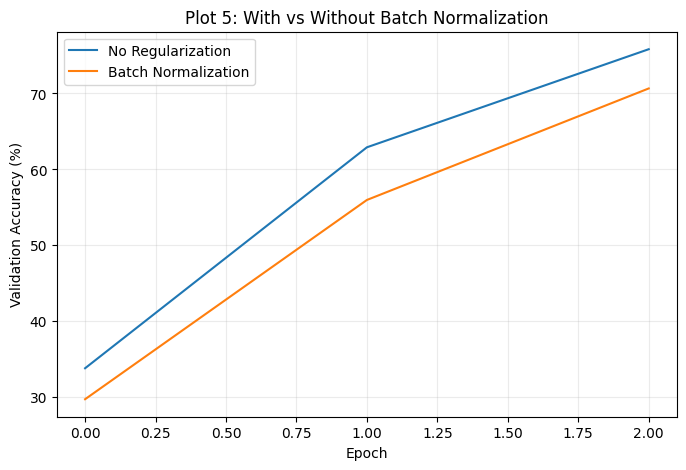

,Configuration,Best Val Accuracy (%),Best Epoch,Time (min)
0,No Regularization,75.815,3,0.033
1,L2,76.902,3,0.037
2,Dropout,63.995,3,0.038
3,Batch Normalization,70.652,3,0.039


In [18]:
regularization = {
    "No Regularization": {"dropout": 0.0, "l2": 0.0, "classifier_bn": False},
    "L2": {"dropout": 0.0, "l2": 1e-4, "classifier_bn": False},
    "Dropout": {"dropout": 0.5, "l2": 0.0, "classifier_bn": False},
    "Batch Normalization": {"dropout": 0.0, "l2": 0.0, "classifier_bn": True},
}
reg_histories, reg_times = {}, {}

for name, cfg in regularization.items():
    print(f"\n=== Regularization: {name} ===")
    cleanup()
    model = make_head_model(**cfg, opt="Adam", lr=1e-4)
    start = time.time()
    h = fit_model(model, STUDY_EPOCHS, feature_train_ds, feature_val_ds)
    reg_histories[name] = h
    reg_times[name] = (time.time() - start) / 60

plt.figure(figsize=(9,5))
for name,h in reg_histories.items():
    plt.plot(np.array(h.history["accuracy"])*100, label=name+" Train")
    plt.plot(np.array(h.history["val_accuracy"])*100, "--", label=name+" Val")
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
plt.title("Plot 3: Training and Validation Accuracy — Regularization")
plt.legend(fontsize=8); plt.grid(alpha=0.25)
savefig("3_regularization_accuracy.png"); plt.show()

plt.figure(figsize=(9,5))
for name,h in reg_histories.items():
    plt.plot(h.history["loss"], label=name+" Train")
    plt.plot(h.history["val_loss"], "--", label=name+" Val")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Plot 4: Training and Validation Loss — Regularization")
plt.legend(fontsize=8); plt.grid(alpha=0.25)
savefig("4_regularization_loss.png"); plt.show()

plt.figure(figsize=(8,5))
for name in ["No Regularization","Batch Normalization"]:
    plt.plot(np.array(reg_histories[name].history["val_accuracy"])*100, label=name)
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 5: With vs Without Batch Normalization")
plt.legend(); plt.grid(alpha=0.25)
savefig("5_batch_normalization.png"); plt.show()

reg_summary = pd.DataFrame({
    "Configuration": list(reg_histories),
    "Best Val Accuracy (%)": [best_val_accuracy(reg_histories[k]) for k in reg_histories],
    "Best Epoch": [best_epoch(reg_histories[k]) for k in reg_histories],
    "Time (min)": [reg_times[k] for k in reg_histories],
})
display(reg_summary.round(3))


## Optimization Algorithms

SGD, Momentum, RMSProp and Adam are compared with the same pretrained frozen backbone, classifier head, learning rate and batch size. This isolates the optimizer as the main changed factor.



=== Optimizer: SGD ===
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.0605 - loss: 4.0158 - val_accuracy: 0.1304 - val_loss: 3.3859
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1695 - loss: 3.1252 - val_accuracy: 0.2677 - val_loss: 2.7674
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3213 - loss: 2.4395 - val_accuracy: 0.3899 - val_loss: 2.2111

=== Optimizer: Momentum ===
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4643 - loss: 2.0825 - val_accuracy: 0.7745 - val_loss: 1.1427
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8522 - loss: 0.5607 - val_accuracy: 0.8247 - val_loss: 0.6424
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9090 - loss: 0.3679 - val_accuracy: 0.8519 - val_loss: 0.5063

=== Optimizer: RMSProp ===
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7456 - loss: 0.9441 - val_accuracy: 0.8560 - val_loss: 0.5667
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2

,Optimizer,Final Loss,Best Val Accuracy (%),Epoch to Best Val Accuracy,Time (min)
0,SGD,2.4395,38.9946,3,0.0318
1,Momentum,0.3679,85.1902,3,0.0329
2,RMSProp,0.0985,88.7228,3,0.0345
3,Adam,0.1975,87.3641,1,0.0352


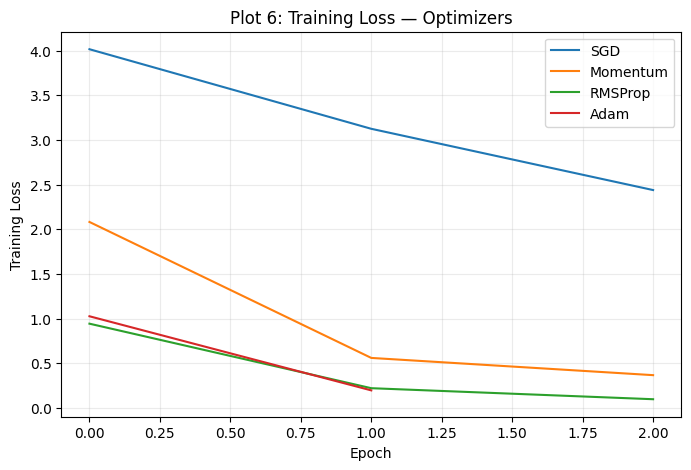

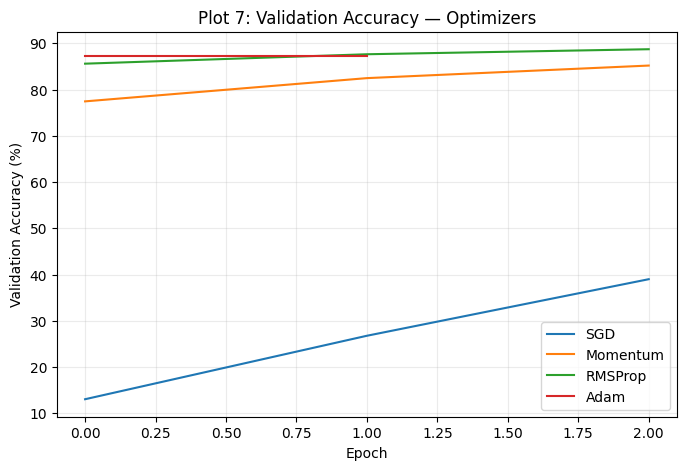

In [19]:
optimizer_names = ["SGD", "Momentum", "RMSProp", "Adam"]
optimizer_histories, optimizer_table_data = {}, []

for opt in optimizer_names:
    print(f"\n=== Optimizer: {opt} ===")
    cleanup()
    model = make_head_model(dropout=0.0, l2=0.0, classifier_bn=True, opt=opt, lr=1e-3)
    start = time.time()
    h = fit_model(model, STUDY_EPOCHS, feature_train_ds, feature_val_ds)
    optimizer_histories[opt] = h
    optimizer_table_data.append({
        "Optimizer": opt, "Final Loss": h.history["loss"][-1],
        "Best Val Accuracy (%)": best_val_accuracy(h),
        "Epoch to Best Val Accuracy": best_epoch(h),
        "Time (min)": (time.time()-start)/60
    })

optimizer_table = pd.DataFrame(optimizer_table_data)
display(optimizer_table.round(4))

plt.figure(figsize=(8,5))
for name,h in optimizer_histories.items(): plt.plot(h.history["loss"], label=name)
plt.xlabel("Epoch"); plt.ylabel("Training Loss")
plt.title("Plot 6: Training Loss — Optimizers"); plt.legend(); plt.grid(alpha=0.25)
savefig("6_optimizers_loss.png"); plt.show()

plt.figure(figsize=(8,5))
for name,h in optimizer_histories.items():
    plt.plot(np.array(h.history["val_accuracy"])*100, label=name)
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 7: Validation Accuracy — Optimizers"); plt.legend(); plt.grid(alpha=0.25)
savefig("7_optimizers_accuracy.png"); plt.show()


## CNN Hyperparameter Tuning

The laboratory explicitly requests one-hyperparameter-at-a-time comparisons. Each run below starts from the same pretrained frozen-backbone baseline and varies only the named hyperparameter.

All suggested values are tested:
- learning rate: `0.001`, `0.0001`;
- batch size: `16`, `32`, `64`;
- dropout: `0`, `0.25`, `0.5`.


In [20]:
# All required one-at-a-time values are tested, but only the 1280-D head is retrained.
def run_hp_experiment(lr=1e-4, dropout=0.0, batch_size=32):
    cleanup()
    tr = make_feature_dataset(X_dev_feat, y_dev_feat, batch_size, True, True)
    va = make_feature_dataset(X_val_feat, y_val_feat, batch_size, False, True)
    model = make_head_model(dropout=dropout, classifier_bn=True, opt="Adam", lr=lr)
    start = time.time()
    h = fit_model(model, STUDY_EPOCHS, tr, va)
    return best_val_accuracy(h), (time.time()-start)/60

lr_results = {lr: run_hp_experiment(lr=lr) for lr in [1e-3, 1e-4]}
batch_results = {bs: run_hp_experiment(batch_size=bs) for bs in [16, 32, 64]}
dropout_results = {d: run_hp_experiment(dropout=d) for d in [0.0, 0.25, 0.5]}

hp_summary = pd.DataFrame({
    "Learning Rate": pd.Series({k:v[0] for k,v in lr_results.items()}),
    "Batch Size": pd.Series({k:v[0] for k,v in batch_results.items()}),
    "Dropout": pd.Series({k:v[0] for k,v in dropout_results.items()}),
})
display(hp_summary)

best_lr = max(lr_results, key=lambda k: lr_results[k][0])
best_batch = max(batch_results, key=lambda k: batch_results[k][0])
best_dropout = max(dropout_results, key=lambda k: dropout_results[k][0])
print("Best one-at-a-time learning rate:", best_lr)
print("Best one-at-a-time batch size:", best_batch)
print("Best one-at-a-time dropout:", best_dropout)


Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7001 - loss: 1.0842 - val_accuracy: 0.8601 - val_loss: 0.5627
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9470 - loss: 0.2030 - val_accuracy: 0.8791 - val_loss: 0.3887
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9868 - loss: 0.0946 - val_accuracy: 0.8764 - val_loss: 0.3525
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.1315 - loss: 3.5046 - val_accuracy: 0.2826 - val_loss: 2.6979
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4823 - loss: 1.9172 - val_accuracy: 0.5910 - val_loss: 1.6508
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7041 - loss: 1.1643 - val_accuracy: 0.7174 - val_loss: 1.0935
Epoch 1/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2303 - loss: 2.9695 - val_accuracy: 0.4986 - val_loss: 1.9849
Epoch 2/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6427 - loss: 1.3555 - val_accuracy: 0.7378 - val_loss: 

,Learning Rate,Batch Size,Dropout
0.0000,NaN,NaN,70.923913
0.0001,71.739131,NaN,NaN
0.0010,87.907606,NaN,NaN
0.2500,NaN,NaN,71.875000
0.5000,NaN,NaN,65.353262
16.0000,NaN,79.891306,NaN
32.0000,NaN,70.380437,NaN
64.0000,NaN,62.635869,NaN


Best one-at-a-time learning rate: 0.001
Best one-at-a-time batch size: 16
Best one-at-a-time dropout: 0.25


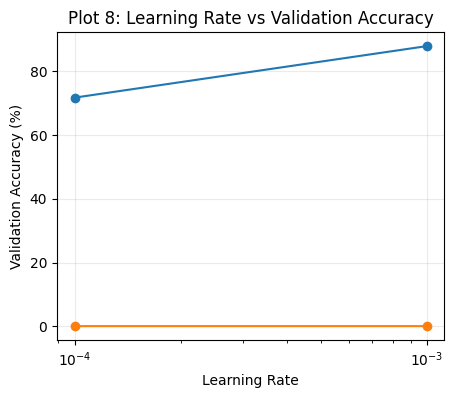

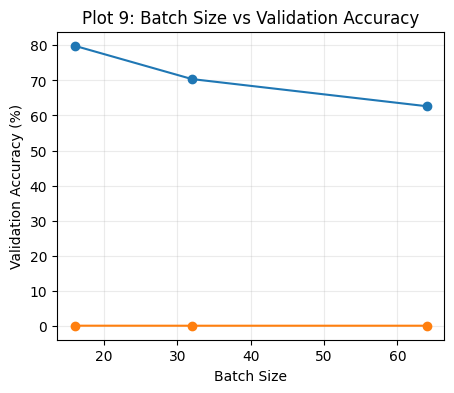

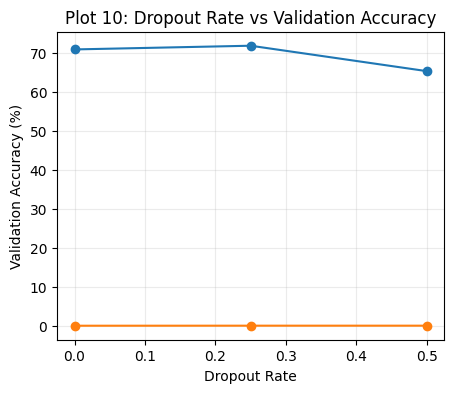

Best one-at-a-time learning rate: 0.001
Best one-at-a-time batch size: 16
Best one-at-a-time dropout: 0.25


In [21]:
# Plot 8: Learning Rate vs Validation Accuracy
plt.figure(figsize=(5, 4))
plt.plot(list(lr_results.keys()), list(lr_results.values()), marker="o")
plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 8: Learning Rate vs Validation Accuracy")
plt.grid(alpha=0.25)
savefig("8_learning_rate.png")
plt.show()

# Plot 9: Batch Size vs Validation Accuracy
plt.figure(figsize=(5, 4))
plt.plot(list(batch_results.keys()), list(batch_results.values()), marker="o")
plt.xlabel("Batch Size")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 9: Batch Size vs Validation Accuracy")
plt.grid(alpha=0.25)
savefig("9_batch_size.png")
plt.show()

# Plot 10: Dropout Rate vs Validation Accuracy
plt.figure(figsize=(5, 4))
plt.plot(list(dropout_results.keys()), list(dropout_results.values()), marker="o")
plt.xlabel("Dropout Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 10: Dropout Rate vs Validation Accuracy")
plt.grid(alpha=0.25)
savefig("10_dropout_rate.png")
plt.show()

best_lr = max(lr_results, key=lr_results.get)
best_batch = max(batch_results, key=batch_results.get)
best_dropout = max(dropout_results, key=dropout_results.get)

print("Best one-at-a-time learning rate:", best_lr)
print("Best one-at-a-time batch size:", best_batch)
print("Best one-at-a-time dropout:", best_dropout)


## Transfer Learning and Fine-Tuning

To reduce GPU time, frozen feature extraction reuses the one-time MobileNetV2
feature cache. Fine-tuning still runs MobileNetV2 end-to-end with a small
learning rate, but only the **last 10 non-BatchNorm layers** are unfrozen.
This satisfies partial unfreezing while reducing backpropagation cost.


In [22]:
# Case A: Feature extraction — cached MobileNetV2 features, so only the head trains.
cleanup()
feature_model = make_head_model(dropout=0.25, classifier_bn=True, opt="Adam", lr=1e-4)
start = time.time()
feature_history = fit_model(feature_model, STUDY_EPOCHS, feature_train_ds, feature_val_ds)
feature_time = (time.time()-start)/60

# Case B: Fine-tuning — actual MobileNetV2 with a small LR and partial unfreezing.
cleanup()
fine_model = make_model(weights="imagenet", train_base=False, dropout=0.25,
                        classifier_bn=True, opt="Adam", lr=1e-5)
fine_model = set_fine_tuning(fine_model, unfreeze_last=10, lr=1e-5)
start = time.time()
fine_history = fit_model(fine_model, STUDY_EPOCHS, train_ds, val_ds)
fine_time = (time.time()-start)/60

print(f"Feature extraction best val accuracy: {best_val_accuracy(feature_history):.2f}%")
print(f"Fine-tuning best val accuracy: {best_val_accuracy(fine_history):.2f}%")
print(f"Fine-tuning unfreezes last 10 non-BN backbone layers.")


Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.1349 - loss: 3.5927 - val_accuracy: 0.2853 - val_loss: 2.6946
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3957 - loss: 2.1613 - val_accuracy: 0.5829 - val_loss: 1.7266
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5944 - loss: 1.4335 - val_accuracy: 0.7052 - val_loss: 1.1701
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 226ms/step - accuracy: 0.0713 - loss: 4.0883 - val_accuracy: 0.1848 - val_loss: 3.0859
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.2459 - loss: 2.8743 - val_accuracy: 0.4375 - val_loss: 2.2185
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.4562 - loss: 2.0438 - val_accuracy: 0.6005 - val_loss: 1.5990
Feature extraction best val accuracy: 70.52%
Fine-tuning best val accuracy: 60.05%
Fine-tuning unfreezes last 10 non-BN backbone layers.


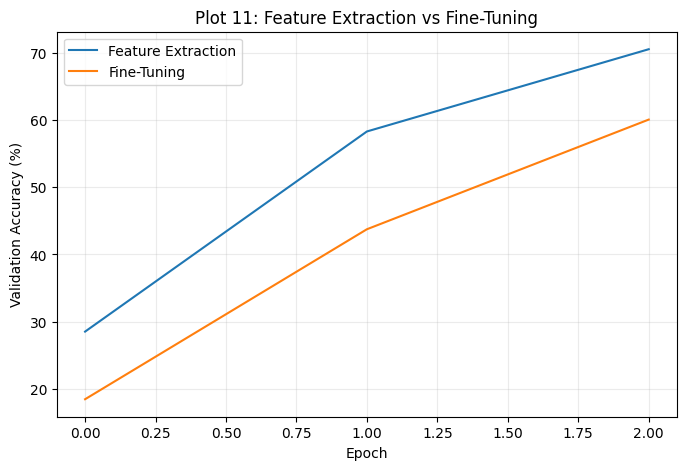

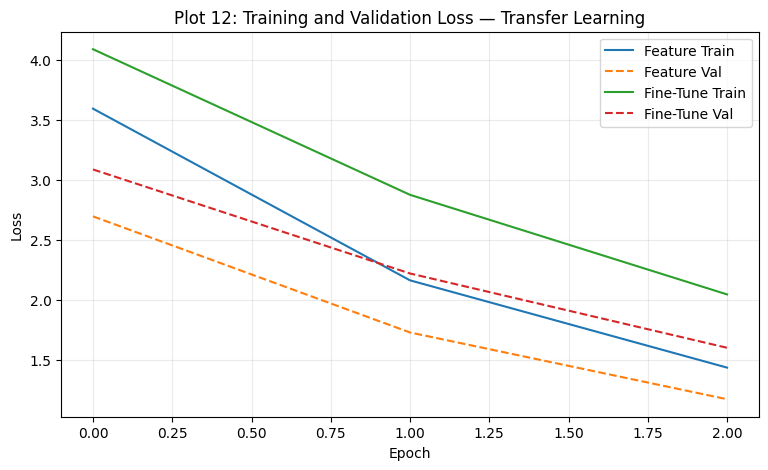

In [23]:
# Plot 11: Feature Extraction vs Fine-Tuning validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(np.array(feature_history.history["val_accuracy"]) * 100, label="Feature Extraction")
plt.plot(np.array(fine_history.history["val_accuracy"]) * 100, label="Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 11: Feature Extraction vs Fine-Tuning")
plt.legend()
plt.grid(alpha=0.25)
savefig("11_feature_extraction_vs_finetuning.png")
plt.show()

# Plot 12: Training and validation loss before/after fine-tuning
plt.figure(figsize=(9, 5))
plt.plot(feature_history.history["loss"], label="Feature Train")
plt.plot(feature_history.history["val_loss"], "--", label="Feature Val")
plt.plot(fine_history.history["loss"], label="Fine-Tune Train")
plt.plot(fine_history.history["val_loss"], "--", label="Fine-Tune Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Plot 12: Training and Validation Loss — Transfer Learning")
plt.legend()
plt.grid(alpha=0.25)
savefig("12_transfer_learning_loss.png")
plt.show()


## Five-Fold Cross-Validation

The CV stage is performed **only on the development training data** (the original training split's 80% development portion). Six configurations are evaluated:
- C1–C4 are the four primary configurations.
- C5–C6 are the two additional-exercise combinations.

The use of `StratifiedKFold(n_splits=5)` preserves class proportions in each fold. The independent test set is still untouched.


In [24]:
# Candidate configurations: 4 primary + 2 required additional combinations.
# Frozen configurations use cached MobileNetV2 features during CV; fine=True uses real fine-tuning.
configs = {
    "C1": {"lr":1e-4, "dropout":0.0, "batch":32, "fine":False,
           "description":"Baseline feature extraction"},
    "C2": {"lr":best_lr, "dropout":best_dropout, "batch":best_batch, "fine":False,
           "description":"Best one-at-a-time hyperparameters, feature extraction"},
    "C3": {"lr":1e-5, "dropout":0.25, "batch":32, "fine":True,
           "description":"Fine-tuning with small LR"},
    "C4": {"lr":1e-5, "dropout":best_dropout, "batch":best_batch, "fine":True,
           "description":"Combined tuned fine-tuning configuration"},
    "C5": {"lr":1e-4, "dropout":0.5, "batch":16, "fine":True,
           "description":"Additional combination 1"},
    "C6": {"lr":1e-5, "dropout":0.5, "batch":64, "fine":False,
           "description":"Additional combination 2"},
}
config_table = pd.DataFrame(configs).T
display(config_table)


,lr,dropout,batch,fine,description
C1,0.0001,0.0,32,False,Baseline feature extraction
C2,0.001,0.25,16,False,"Best one-at-a-time hyperparameters, feature ex..."
C3,0.00001,0.25,32,True,Fine-tuning with small LR
C4,0.00001,0.25,16,True,Combined tuned fine-tuning configuration
C5,0.0001,0.5,16,True,Additional combination 1
C6,0.00001,0.5,64,False,Additional combination 2


In [25]:
# 5-fold stratified CV.
# Major optimization: frozen-backbone folds train a tiny head on cached features.
# Only fine-tuning configurations perform expensive MobileNetV2 backpropagation.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results, cv_times = {}, {}

for cname, cfg in configs.items():
    print(f"\n================ {cname}: {cfg['description']} ================")
    scores = []
    start_config = time.time()

    for fold, (tr, va) in enumerate(skf.split(X_dev, y_dev), start=1):
        print(f"Fold {fold}/5")
        cleanup()

        if cfg["fine"]:
            tr_ds = make_array_dataset(X_dev[tr], y_dev[tr], cfg["batch"], True)
            va_ds = make_array_dataset(X_dev[va], y_dev[va], cfg["batch"], False, True)
            model = make_model(weights="imagenet", train_base=False,
                               dropout=cfg["dropout"], classifier_bn=True,
                               opt="Adam", lr=cfg["lr"])
            model = set_fine_tuning(model, unfreeze_last=10, lr=cfg["lr"], opt="Adam")
        else:
            tr_ds = make_feature_dataset(X_dev_feat[tr], y_dev_feat[tr],
                                         cfg["batch"], True, True)
            va_ds = make_feature_dataset(X_dev_feat[va], y_dev_feat[va],
                                         cfg["batch"], False, True)
            model = make_head_model(dropout=cfg["dropout"], classifier_bn=True,
                                    opt="Adam", lr=cfg["lr"])

        h = fit_model(model, CV_EPOCHS, tr_ds, va_ds)
        score = best_val_accuracy(h)
        scores.append(score)
        print(f"Fold {fold}: {score:.2f}%")

    cv_results[cname] = scores
    cv_times[cname] = (time.time()-start_config)/60
    print(f"{cname}: mean={np.mean(scores):.2f}% | SD={np.std(scores,ddof=0):.2f}%")

cv_table = pd.DataFrame(cv_results, index=[f"F{i}" for i in range(1,6)]).T
cv_table["Mean"] = cv_table.iloc[:,:5].mean(axis=1)
cv_table["SD"] = cv_table.iloc[:,:5].std(axis=1, ddof=0)
cv_table["Time (min)"] = pd.Series(cv_times)
display(cv_table.round(3))



================ C1: Baseline feature extraction ================
Fold 1/5
Epoch 1/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.1291 - loss: 3.4358 - val_accuracy: 0.2343 - val_loss: 2.8125
Epoch 2/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4378 - loss: 2.0698 - val_accuracy: 0.5382 - val_loss: 1.8942
Fold 1: 53.82%
Fold 2/5
Epoch 1/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.1253 - loss: 3.4763 - val_accuracy: 0.2767 - val_loss: 2.7334
Epoch 2/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4340 - loss: 2.0897 - val_accuracy: 0.5705 - val_loss: 1.8004
Fold 2: 57.05%
Fold 3/5
Epoch 1/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.1312 - loss: 3.4710 - val_accuracy: 0.2666 - val_loss: 2.7406
Epoch 2/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4340 - loss: 2.0893 - val_accuracy: 0.5739 - val_loss: 1.7965
Fold 3: 57.39%
Fold 4/5
Epoch 1/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.1023 - loss: 3.6737 - val_accuracy:

2026-08-30 08:56:34.470755: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 08:56:34.608014: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


80/74 ━━━━━━━━━━━━━━━━━━━━━ -2s 339ms/step - accuracy: 0.0407 - loss: 4.6087

2026-08-30 08:56:52.709001: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 08:56:52.846817: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


74/74 ━━━━━━━━━━━━━━━━━━━━ 44s 599ms/step - accuracy: 0.0561 - loss: 4.3651 - val_accuracy: 0.0985 - val_loss: 3.4320
Epoch 2/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.1592 - loss: 3.2863 - val_accuracy: 0.2784 - val_loss: 2.7107
Fold 1: 27.84%
Fold 2/5
Epoch 1/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 30s 402ms/step - accuracy: 0.0471 - loss: 4.2955 - val_accuracy: 0.1205 - val_loss: 3.3273
Epoch 2/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.1580 - loss: 3.2720 - val_accuracy: 0.2801 - val_loss: 2.6648
Fold 2: 28.01%
Fold 3/5
Epoch 1/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 30s 404ms/step - accuracy: 0.0561 - loss: 4.2686 - val_accuracy: 0.1154 - val_loss: 3.2343
Epoch 2/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.1720 - loss: 3.2302 - val_accuracy: 0.3616 - val_loss: 2.4807
Fold 3: 36.16%
Fold 4/5
Epoch 1/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 30s 401ms/step - accuracy: 0.0684 - loss: 4.1029 - val_accuracy: 0.1596 - val_loss: 3.1357
Epoch 2/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/ste

...

2026-08-30 09:00:22.165040: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 09:00:22.302381: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


148/148 ━━━━━━━━━━━━━━━━━━━━ 46s 309ms/step - accuracy: 0.0662 - loss: 4.0858 - val_accuracy: 0.2037 - val_loss: 3.0334
Epoch 2/2
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.2505 - loss: 2.7899 - val_accuracy: 0.4839 - val_loss: 2.0783
Fold 1: 48.39%
Fold 2/5
Epoch 1/2
148/148 ━━━━━━━━━━━━━━━━━━━━ 30s 205ms/step - accuracy: 0.0510 - loss: 4.2435 - val_accuracy: 0.1443 - val_loss: 3.1033
Epoch 2/2
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.2272 - loss: 2.8942 - val_accuracy: 0.4278 - val_loss: 2.1076
Fold 2: 42.78%
Fold 3/5
Epoch 1/2
148/148 ━━━━━━━━━━━━━━━━━━━━ 30s 203ms/step - accuracy: 0.0837 - loss: 4.0185 - val_accuracy: 0.1851 - val_loss: 2.9881
Epoch 2/2
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.2739 - loss: 2.7761 - val_accuracy: 0.4652 - val_loss: 2.0011
Fold 3: 46.52%
Fold 4/5
Epoch 1/2
148/148 ━━━━━━━━━━━━━━━━━━━━ 30s 203ms/step - accuracy: 0.0794 - loss: 4.0325 - val_accuracy: 0.2173 - val_loss: 2.9765
Epoch 2/2
148/148 ━━━━━━━━━━━━━━━━

2026-08-30 09:03:06.160760: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 09:03:06.309943: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 09:03:06.447014: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


148/148 ━━━━━━━━━━━━━━━━━━━━ 38s 256ms/step - accuracy: 0.0624 - loss: 4.2345 - val_accuracy: 0.2075 - val_loss: 3.0400
Epoch 2/2
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.2271 - loss: 2.9563 - val_accuracy: 0.4745 - val_loss: 2.1321
Fold 5: 47.45%
C4: mean=46.40% | SD=1.92%

================ C5: Additional combination 1 ================
Fold 1/5
Epoch 1/2
148/148 ━━━━━━━━━━━━━━━━━━━━ 30s 205ms/step - accuracy: 0.4425 - loss: 2.2430 - val_accuracy: 0.7368 - val_loss: 0.8939
Epoch 2/2
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7983 - loss: 0.6752 - val_accuracy: 0.8489 - val_loss: 0.4892
Fold 1: 84.89%
Fold 2/5
Epoch 1/2
148/148 ━━━━━━━━━━━━━━━━━━━━ 30s 205ms/step - accuracy: 0.4085 - loss: 2.3728 - val_accuracy: 0.7606 - val_loss: 0.8811
Epoch 2/2
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7915 - loss: 0.7090 - val_accuracy: 0.8778 - val_loss: 0.4706
Fold 2: 87.78%
Fold 3/5
Epoch 1/2
148/148 ━━━━━━━━━━━━━━━━━━━━ 30s 203ms/step - accuracy: 0.4242 

,F1,F2,F3,F4,F5,Mean,SD,Time (min)
C1,53.820,57.046,57.385,52.971,56.293,55.503,1.777,0.480
C2,88.285,92.530,89.474,89.134,88.946,89.674,1.480,0.576
C3,27.844,28.014,36.163,35.993,31.293,31.861,3.656,3.644
C4,48.387,42.784,46.520,46.859,47.449,46.400,1.916,3.642
C5,84.890,87.776,87.097,84.380,86.565,86.141,1.299,3.280
C6,1.019,5.433,4.754,2.716,4.252,3.635,1.585,0.651


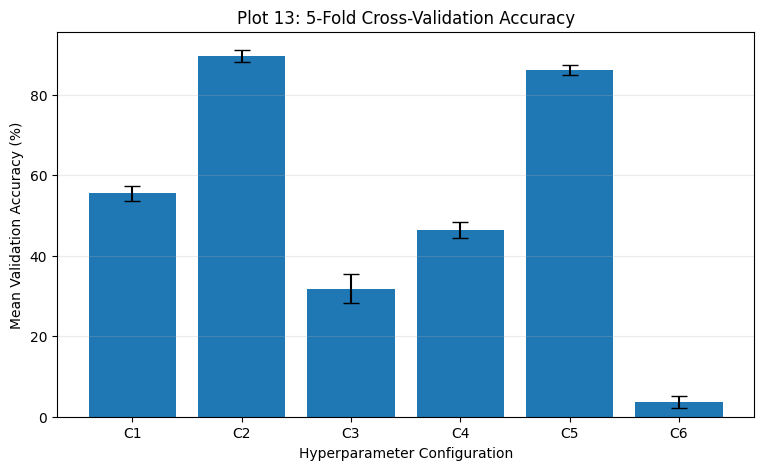

Selected configuration: C2
{'lr': 0.001, 'dropout': 0.25, 'batch': 16, 'fine': False, 'description': 'Best one-at-a-time hyperparameters, feature extraction'}


In [26]:
# Plot 13: 5-fold CV mean accuracy with population SD error bars
plt.figure(figsize=(9, 5))
x = np.arange(len(cv_table.index))
plt.bar(x, cv_table["Mean"], yerr=cv_table["SD"], capsize=6)
plt.xticks(x, cv_table.index)
plt.xlabel("Hyperparameter Configuration")
plt.ylabel("Mean Validation Accuracy (%)")
plt.title("Plot 13: 5-Fold Cross-Validation Accuracy")
plt.grid(axis="y", alpha=0.25)
savefig("13_cross_validation_accuracy.png")
plt.show()

best_config_name = cv_table["Mean"].idxmax()
best_config = configs[best_config_name]

print("Selected configuration:", best_config_name)
print(best_config)


## Final Model Evaluation

The selected configuration is retrained on **all 3,680 original training
examples**. Frozen feature-extraction configurations use the cached
MobileNetV2 representation; a selected fine-tuning configuration performs
actual partial fine-tuning. The independent test set is untouched until
after selection.


In [27]:
# Retrain the selected configuration on all original training examples.
cleanup()

if best_config["fine"]:
    final_model = make_model(weights="imagenet", train_base=False,
                             dropout=best_config["dropout"], classifier_bn=True,
                             opt="Adam", lr=best_config["lr"])
    final_model = set_fine_tuning(final_model, unfreeze_last=10,
                                  lr=best_config["lr"], opt="Adam")
    final_data = full_train_ds = make_array_dataset(
        train_images, train_labels, best_config["batch"], training=True
    )
else:
    final_model = make_head_model(dropout=best_config["dropout"],
                                  classifier_bn=True, opt="Adam",
                                  lr=best_config["lr"])
    final_data = make_feature_dataset(
        X_full_feat, y_full_feat, best_config["batch"], training=True, cache=True
    )

start = time.time()
final_history = fit_model(final_model, FINAL_EPOCHS, final_data, validation=None)
training_time = (time.time()-start)/60

print(f"Final training time: {training_time:.2f} min")
print("Trainable parameters:", sum(np.prod(v.shape) for v in final_model.trainable_weights))
print("Total parameters:", final_model.count_params())


Epoch 1/6
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7174 - loss: 0.9774
Epoch 2/6
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9228 - loss: 0.2334
Epoch 3/6
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9606 - loss: 0.1295
Epoch 4/6
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9818 - loss: 0.0763
Epoch 5/6
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9932 - loss: 0.0447
Epoch 6/6
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9918 - loss: 0.0342
Final training time: 0.06 min
Trainable parameters: 49957
Total parameters: 52517


In [28]:
# Evaluate only now on the untouched independent test set.
if best_config["fine"]:
    eval_ds = test_ds
    y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
else:
    # Only now are test images loaded and passed through the frozen backbone.
    test_images, test_labels = materialize_resized(ds_test_raw)
    eval_base = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet"
    )
    eval_extractor = tf.keras.Sequential([
        tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        eval_base,
        tf.keras.layers.GlobalAveragePooling2D()
    ])
    eval_ds_raw = make_array_dataset(test_images, test_labels, 128, False, False)
    X_test_feat = eval_extractor.predict(eval_ds_raw, verbose=0).astype(np.float32)
    y_true = test_labels
    del eval_extractor, eval_base, test_images, test_labels
    gc.collect()
    eval_ds = make_feature_dataset(X_test_feat, y_true, best_config["batch"], False, True)

test_loss, test_accuracy = final_model.evaluate(eval_ds, verbose=1)
probs = final_model.predict(eval_ds, verbose=0)
y_pred = np.argmax(probs, axis=1)

report = classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0
)
precision = report["weighted avg"]["precision"]
recall = report["weighted avg"]["recall"]
f1 = report["weighted avg"]["f1-score"]

mean_cv = cv_table.loc[best_config_name, "Mean"]
sd_cv = cv_table.loc[best_config_name, "SD"]

final_table = pd.DataFrame({
    "Metric": ["Mean CV Accuracy","CV Standard Deviation","Test Accuracy",
               "Precision (weighted)","Recall (weighted)","F1-score (weighted)",
               "Training Time (min)","Number of Parameters"],
    "Value": [f"{mean_cv:.2f}%", f"{sd_cv:.2f}%", f"{test_accuracy*100:.2f}%",
              f"{precision*100:.2f}%", f"{recall*100:.2f}%", f"{f1*100:.2f}%",
              f"{training_time:.2f}", f"{final_model.count_params():,}"]
})
display(final_table)


2026-08-30 09:07:48.671095: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 09:07:48.823123: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 09:08:06.463133: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 09:08:06.606099: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8858 - loss: 0.4206


,Metric,Value
0,Mean CV Accuracy,89.67%
1,CV Standard Deviation,1.48%
2,Test Accuracy,88.58%
3,Precision (weighted),89.36%
4,Recall (weighted),88.58%
5,F1-score (weighted),88.59%
6,Training Time (min),0.06
7,Number of Parameters,"52,517"


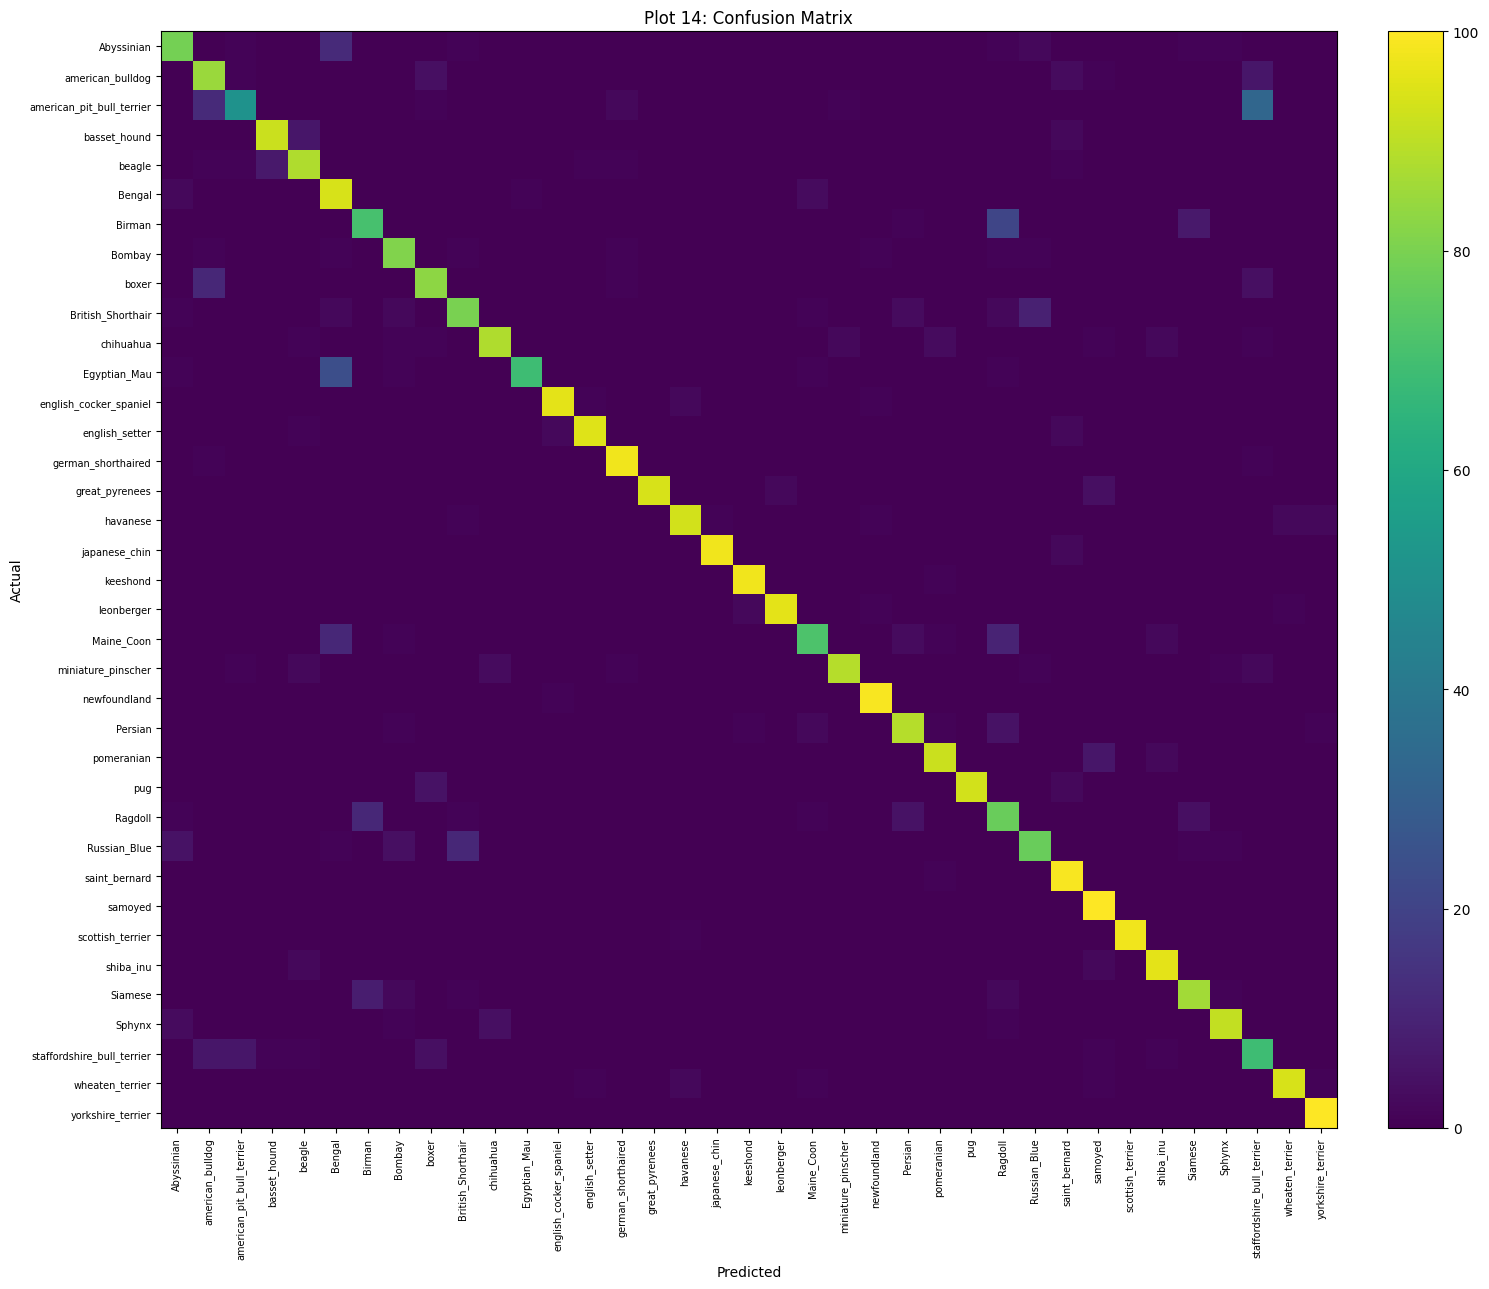

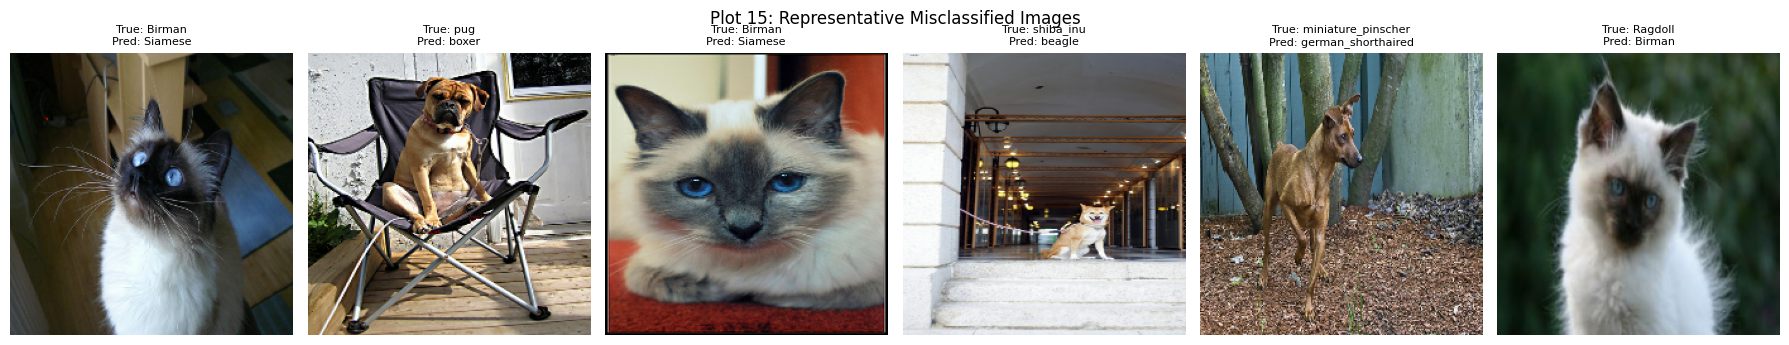

In [29]:
# Plot 14: Confusion matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(15, 13))
im = ax.imshow(cm, interpolation="nearest", aspect="auto")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set(
    xticks=np.arange(NUM_CLASSES),
    yticks=np.arange(NUM_CLASSES),
    xticklabels=class_names,
    yticklabels=class_names,
    xlabel="Predicted",
    ylabel="Actual",
    title="Plot 14: Confusion Matrix",
)
plt.setp(ax.get_xticklabels(), rotation=90, ha="center", fontsize=7)
plt.setp(ax.get_yticklabels(), fontsize=7)
fig.tight_layout()
savefig("14_confusion_matrix.png")
plt.show()

# Plot 15: representative misclassified images
misclassified_idx = np.flatnonzero(y_true != y_pred)
n_show = min(6, len(misclassified_idx))

if n_show:
    # Reuse the already-materialized test images without unbatch/skip loops.
    test_images, _ = materialize_resized(ds_test_raw)
    fig, axes = plt.subplots(1, n_show, figsize=(3*n_show, 3.5))
    if n_show == 1:
        axes = [axes]
    for ax, idx in zip(axes, misclassified_idx[:n_show]):
        ax.imshow(test_images[idx])
        ax.set_title(
            f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}",
            fontsize=8,
        )
        ax.axis("off")
    fig.suptitle("Plot 15: Representative Misclassified Images")
    fig.tight_layout()
    savefig("15_misclassified_images.png")
    plt.show()
else:
    print("No misclassified test images; Plot 15 is not applicable.")


In [30]:
# Overall results table
best_init_name = init_summary.loc[init_summary["Best Val Accuracy (%)"].idxmax(), "Initialization"]
best_reg_name = reg_summary.loc[reg_summary["Best Val Accuracy (%)"].idxmax(), "Configuration"]
best_opt_name = optimizer_table.loc[
    optimizer_table["Best Val Accuracy (%)"].idxmax(), "Optimizer"
]

overall_results = [
    {
        "Configuration": "Baseline",
        "CV Accuracy": "-",
        "SD": "-",
        "Test Accuracy": "-",
        "Training Time": "-"
    },
    {
        "Configuration": f"Best Initialization ({best_init_name})",
        "CV Accuracy": "-",
        "SD": "-",
        "Test Accuracy": f"{init_summary['Best Val Accuracy (%)'].max():.2f}% val",
        "Training Time": f"{init_summary.loc[init_summary['Best Val Accuracy (%)'].idxmax(), 'Time (min)']:.2f} min",
    },
    {
        "Configuration": f"Best Regularization ({best_reg_name})",
        "CV Accuracy": "-",
        "SD": "-",
        "Test Accuracy": f"{reg_summary['Best Val Accuracy (%)'].max():.2f}% val",
        "Training Time": f"{reg_summary.loc[reg_summary['Best Val Accuracy (%)'].idxmax(), 'Time (min)']:.2f} min",
    },
    {
        "Configuration": f"Best Optimizer ({best_opt_name})",
        "CV Accuracy": "-",
        "SD": "-",
        "Test Accuracy": f"{optimizer_table['Best Val Accuracy (%)'].max():.2f}% val",
        "Training Time": f"{optimizer_table.loc[optimizer_table['Best Val Accuracy (%)'].idxmax(), 'Time (min)']:.2f} min",
    },
    {
        "Configuration": f"Best Hyperparameters ({best_config_name})",
        "CV Accuracy": f"{mean_cv:.2f}%",
        "SD": f"{sd_cv:.2f}%",
        "Test Accuracy": f"{test_accuracy * 100:.2f}%",
        "Training Time": f"{training_time:.2f} min",
    },
    {
        "Configuration": "Fine-Tuned Model",
        "CV Accuracy": f"{mean_cv:.2f}%",
        "SD": f"{sd_cv:.2f}%",
        "Test Accuracy": f"{test_accuracy * 100:.2f}%",
        "Training Time": f"{training_time:.2f} min",
    },
]

overall_df = pd.DataFrame(overall_results)
display(overall_df)

,Configuration,CV Accuracy,SD,Test Accuracy,Training Time
0,Baseline,-,-,-,-
1,Best Initialization (Zero),-,-,2.72% val,1.46 min
2,Best Regularization (L2),-,-,76.90% val,0.04 min
3,Best Optimizer (RMSProp),-,-,88.72% val,0.03 min
4,Best Hyperparameters (C2),89.67%,1.48%,88.58%,0.06 min
5,Fine-Tuned Model,89.67%,1.48%,88.58%,0.06 min


In [31]:
# Save a machine-readable copy of key result tables for report preparation.
results_dir = os.path.join(RUN_DIR, "results")
os.makedirs(results_dir, exist_ok=True)

init_summary.to_csv(os.path.join(results_dir, "initialization_results.csv"), index=False)
reg_summary.to_csv(os.path.join(results_dir, "regularization_results.csv"), index=False)
optimizer_table.to_csv(os.path.join(results_dir, "optimizer_results.csv"), index=False)
cv_table.to_csv(os.path.join(results_dir, "cross_validation_results.csv"))
final_table.to_csv(os.path.join(results_dir, "final_evaluation.csv"), index=False)
overall_df.to_csv(os.path.join(results_dir, "overall_results.csv"), index=False)

print("Saved result tables to:", results_dir)


Saved result tables to: /kaggle/working/results


In [32]:
# Verify required plot files and package everything for convenient submission.
required_plots = [
    "1_weight_init_loss.png",
    "2_weight_init_accuracy.png",
    "3_regularization_accuracy.png",
    "4_regularization_loss.png",
    "5_batch_normalization.png",
    "6_optimizers_loss.png",
    "7_optimizers_accuracy.png",
    "8_learning_rate.png",
    "9_batch_size.png",
    "10_dropout_rate.png",
    "11_feature_extraction_vs_finetuning.png",
    "12_transfer_learning_loss.png",
    "13_cross_validation_accuracy.png",
    "14_confusion_matrix.png",
    "15_misclassified_images.png",
]

existing = [f for f in required_plots if os.path.exists(os.path.join(IMAGES_DIR, f))]
missing = [f for f in required_plots if f not in existing]

print(f"Required plot files present: {len(existing)}/{len(required_plots)}")
if missing:
    print("Missing until the relevant cells are executed:", missing)
else:
    print("All required plots are present in images/.")

zip_path = shutil.make_archive(
    os.path.join(RUN_DIR, "report_images"),
    "zip",
    IMAGES_DIR
)
print("Image archive:", zip_path)

Required plot files present: 15/15
All required plots are present in images/.
Image archive: /kaggle/working/report_images.zip
